In [1]:
# Forming Paires
# cross family comaprison, holds low infromation value 

# Hard positives and negatives should build majority while minoraty should be diffrent sequences since already seperated by esm2 embeddings
# 80 in family, 20 betwee families
# Do it percentile based so take the lowest percentile eg 20 or 25 and compare it with the active percentile 


# 1. group by id and family 
# 2. sort pairwise activity diffrence
# 3. assign labels based on percentile cutoff
# 4. based on positve and negative paires
# 5. cross family paires 


# Questions:
# - paires only within family or also between
# - between diffrent sets within family by mutation, close to far, ...
# pairing across data sets -> same aa substituition, diffrent activity -> hard paires 



In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from glob import glob

In [3]:
base_dir = '/home/lherrmann/projects/enzyme-design/flip2_Project/test/csv_id/train_df' # Or your specific folder
    
df = pd.concat([pd.read_csv(os.path.join(base_dir, f)) for f in os.listdir(base_dir) ], ignore_index=True)# if f.endswith('.csv')

In [4]:
df.head()
df['uni_scale'].max()


np.float64(0.7434162447121501)

In [5]:
df['id'].str[1:3].unique() 

<StringArray>
['TB']
Length: 1, dtype: str

In [6]:
df_active = df[df['uni_scale'] > 0]


<Axes: xlabel='uni_scale', ylabel='Count'>

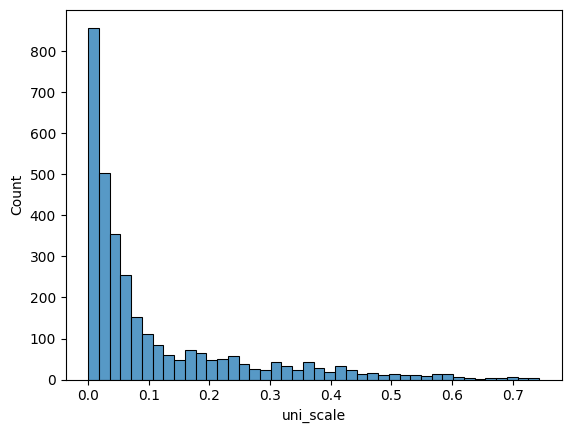

In [7]:
sns.histplot(df_active, x= 'uni_scale')

In [8]:
df_active = df_active[df_active['uni_scale'] >= 0.3]
df_inactive = df[df['uni_scale'] == 0]

In [9]:
#Hamming distance
mat_active = np.array([list(s) for s in df_active['sequence']])  # shape (3, 4)
mat_inactive = np.array([list(s) for s in df_inactive['sequence']])  # shape (3, 4)

mat_active[:, None, :]
mat_inactive[None, :, :]

mismatches = (mat_active[:, None, :] != mat_inactive[None, :, :])

dist_matrix = mismatches.sum(axis=2)

rows, cols = np.where(dist_matrix <= 1)

<Axes: ylabel='Count'>

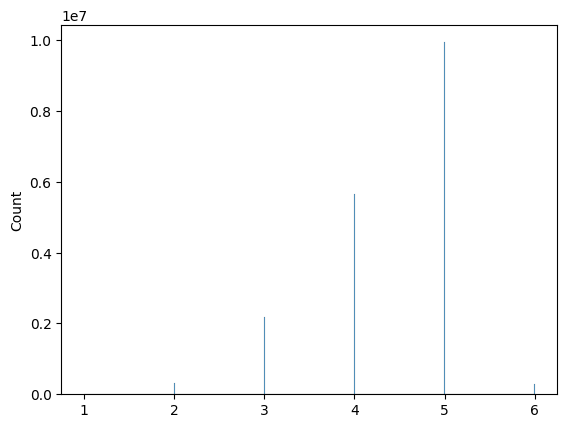

In [10]:
sns.histplot(dist_matrix.flatten())

In [11]:
def pos_paires(n):
    paired_id_pos = []
    seen = set()
    while len(paired_id_pos) < n:
        row_1 = df_active.sample(1)
        row_2 = df_active.sample(1)
        id_1 = row_1['id'].values[0]
        id_2 = row_2['id'].values[0]

        if id_1 == id_2:
            continue

        check = frozenset({id_1, id_2})
        if check in seen:
            continue

        seen.add(check)
        paired_id_pos.append({'id_1': id_1, 'id_2': id_2})
                
    return pd.DataFrame(paired_id_pos)

# def neg_paires(n):
#     paired_id_neg = []
#     double = set()
#     while len(paired_id_neg) < n:
#         row_1 = df_inactive.sample(1)
#         row_2 = df_inactive.sample(1)
#         id_1 = row_1['id'].values[0]
#         id_2 = row_2['id'].values[0]

#         if id_1 == id_2:
#             continue

#         check = frozenset({id_1, id_2})
#         if check in double:
#             continue

#         double.add(check)
#         paired_id_neg.append({'neg_pair_1': id_1, 'neg_pair_2': id_2})

#     return pd.DataFrame(paired_id_neg)


def con_paires(n):
    paired_id_con =[]
    double = set()
    while len(paired_id_con) <n:
        row1 = df_active.sample(1)
        row2 = df_inactive.sample(1)
        id_1 = row1['id'].values[0]
        id_2 = row2['id'].values[0]

        # if id_1 == id_2:
        #     continue

        check = frozenset({id_1, id_2}) 
        if check in double:
            continue

        double.add(check)
        paired_id_con.append({'id_1': id_1, 'id_2': id_2 })

    return pd.DataFrame(paired_id_con)

def trip_loss_paires(n):
    id_pair_trip_loss =[]
    double = set()
    while len(id_pair_trip_loss) <n:
        row1 = df_active.sample(1)
        row2 = df_active.sample(1)
        row3 = df_inactive.sample(1)
        id_1 = row1['id'].values[0]
        id_2 = row2['id'].values[0]
        id_3 = row3['id'].values[0]

        if id_1 == id_2:
            continue

        check = frozenset({id_1, id_2, id_3}) 
        if check in double:
            continue

        double.add(check)
        id_pair_trip_loss.append({'id_1': id_1, 'id_2': id_2, 'id_3': id_3})

    return pd.DataFrame(id_pair_trip_loss)


In [12]:
n=3000

In [13]:
df_pos_paires = pos_paires(n)
df_pos_paires.head()

,id_1,id_2
0,1TB_087652,1TB_069028
1,1TB_101585,1TB_119471
2,1TB_164090,1TB_212768
3,1TB_010078,1TB_112698
4,2TB_166436,1TB_154058


In [14]:
df_pos_paires.insert(2, 'label', 1)
df_pos_paires.head()

,id_1,id_2,label
0,1TB_087652,1TB_069028,1
1,1TB_101585,1TB_119471,1
2,1TB_164090,1TB_212768,1
3,1TB_010078,1TB_112698,1
4,2TB_166436,1TB_154058,1


In [15]:
df_con_paires = con_paires(n)
df_con_paires.insert(2, 'label', -1)
df_con_paires.head()

,id_1,id_2,label
0,3TB_169418,1TB_004715,-1
1,3TB_153898,1TB_209848,-1
2,3TB_021050,3TB_017259,-1
3,2TB_184512,1TB_014349,-1
4,2TB_167229,3TB_207260,-1


In [16]:
df_concat = pd.concat([df_pos_paires, df_con_paires])
df_concat.tail()

,id_1,id_2,label
2995,3TB_081274,1TB_219283,-1
2996,2TB_211283,1TB_013153,-1
2997,1TB_039955,1TB_011963,-1
2998,1TB_211268,1TB_012150,-1
2999,3TB_211284,1TB_012663,-1


In [17]:
# df_trip_loss_paires = trip_loss_paires(n)
# df_trip_loss_paires.head()

In [18]:
base_output_dir = '/home/lherrmann/projects/enzyme-design/flip2_Project/test/csv_id/paires'
df_concat.to_csv(base_output_dir + '/df_paires.csv', index= False)
# df_pos_paires.to_csv(base_output_dir + '/df_pos_paires.csv', index= False)
# df_neg_paires.to_csv(base_output_dir + '/df_neg_paires.csv', index= False)
# df_con_paires.to_csv(base_output_dir + '/df_con_paires.csv', index= False)
# df_trip_loss_paires.to_csv(base_output_dir + '/df_trip_loss_paires.csv', index= False)
